In [545]:
from datetime import datetime
from operator import index
from random import random
import random
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow
from tensorflow.keras.models import (Sequential, load_model, Model)
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import (Dense, Dropout, Conv1D, GRU, Bidirectional, LSTM, Flatten, Input, concatenate)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint)
from sklearn.metrics import (r2_score, mean_absolute_error)
from math import ceil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("../Projektdatensaetze_angepasst/2023/Fahrradzaehlstellen2023_stuendlich.csv")
df.head()

,time,Kennedybruecke (Nord),Kennedybruecke (Sued) Barometer,Nordbruecke (Sued),Nordbruecke (Nord),Suedbruecke (Sued),Suedbruecke (Nord),Estermannufer,Von-Sandt-Ufer,Rhenusallee,Broehltalweg,Bruehler Straße,Wilhelm-Spiritus-Ufer,Mc Cloy Weg,Weg auf Damm Neil,Kennedybruecke,Nordbruecke,Suedbruecke,days
0,2023-01-01 00:00:00,26.0,25.0,2.0,1.0,12.0,10.0,0.0,3.0,0.0,1.0,3.0,12.0,0.0,8.0,51.0,3.0,22.0,2023-01-01
1,2023-01-01 01:00:00,46.0,88.0,11.0,2.0,15.0,10.0,1.0,5.0,0.0,10.0,13.0,26.0,2.0,12.0,134.0,13.0,25.0,2023-01-01
2,2023-01-01 02:00:00,63.0,80.0,4.0,10.0,11.0,16.0,2.0,3.0,0.0,16.0,3.0,11.0,4.0,13.0,143.0,14.0,27.0,2023-01-01
3,2023-01-01 03:00:00,34.0,66.0,6.0,3.0,16.0,5.0,2.0,3.0,0.0,2.0,6.0,7.0,3.0,10.0,100.0,9.0,21.0,2023-01-01
4,2023-01-01 04:00:00,22.0,32.0,4.0,0.0,5.0,3.0,0.0,4.0,0.0,2.0,1.0,7.0,2.0,12.0,54.0,4.0,8.0,2023-01-01


In [546]:
df['Kennedybruecke (Nord)'].dtype

dtype('float64')

In [547]:
df['time'].dtype

dtype('O')

In [548]:
df['time'] = pd.to_datetime(df['time'], format='%Y-%m-%d %H:%M:%S')

In [549]:
df['time'].dtype

dtype('<M8[ns]')

In [550]:
df['month'] = df['time'].dt.month
df.head()

,time,Kennedybruecke (Nord),Kennedybruecke (Sued) Barometer,Nordbruecke (Sued),Nordbruecke (Nord),Suedbruecke (Sued),Suedbruecke (Nord),Estermannufer,Von-Sandt-Ufer,Rhenusallee,Broehltalweg,Bruehler Straße,Wilhelm-Spiritus-Ufer,Mc Cloy Weg,Weg auf Damm Neil,Kennedybruecke,Nordbruecke,Suedbruecke,days,month
0,2023-01-01 00:00:00,26.0,25.0,2.0,1.0,12.0,10.0,0.0,3.0,0.0,1.0,3.0,12.0,0.0,8.0,51.0,3.0,22.0,2023-01-01,1
1,2023-01-01 01:00:00,46.0,88.0,11.0,2.0,15.0,10.0,1.0,5.0,0.0,10.0,13.0,26.0,2.0,12.0,134.0,13.0,25.0,2023-01-01,1
2,2023-01-01 02:00:00,63.0,80.0,4.0,10.0,11.0,16.0,2.0,3.0,0.0,16.0,3.0,11.0,4.0,13.0,143.0,14.0,27.0,2023-01-01,1
3,2023-01-01 03:00:00,34.0,66.0,6.0,3.0,16.0,5.0,2.0,3.0,0.0,2.0,6.0,7.0,3.0,10.0,100.0,9.0,21.0,2023-01-01,1
4,2023-01-01 04:00:00,22.0,32.0,4.0,0.0,5.0,3.0,0.0,4.0,0.0,2.0,1.0,7.0,2.0,12.0,54.0,4.0,8.0,2023-01-01,1


In [551]:
df.drop('month', axis=1, inplace=True)
df.head()

,time,Kennedybruecke (Nord),Kennedybruecke (Sued) Barometer,Nordbruecke (Sued),Nordbruecke (Nord),Suedbruecke (Sued),Suedbruecke (Nord),Estermannufer,Von-Sandt-Ufer,Rhenusallee,Broehltalweg,Bruehler Straße,Wilhelm-Spiritus-Ufer,Mc Cloy Weg,Weg auf Damm Neil,Kennedybruecke,Nordbruecke,Suedbruecke,days
0,2023-01-01 00:00:00,26.0,25.0,2.0,1.0,12.0,10.0,0.0,3.0,0.0,1.0,3.0,12.0,0.0,8.0,51.0,3.0,22.0,2023-01-01
1,2023-01-01 01:00:00,46.0,88.0,11.0,2.0,15.0,10.0,1.0,5.0,0.0,10.0,13.0,26.0,2.0,12.0,134.0,13.0,25.0,2023-01-01
2,2023-01-01 02:00:00,63.0,80.0,4.0,10.0,11.0,16.0,2.0,3.0,0.0,16.0,3.0,11.0,4.0,13.0,143.0,14.0,27.0,2023-01-01
3,2023-01-01 03:00:00,34.0,66.0,6.0,3.0,16.0,5.0,2.0,3.0,0.0,2.0,6.0,7.0,3.0,10.0,100.0,9.0,21.0,2023-01-01
4,2023-01-01 04:00:00,22.0,32.0,4.0,0.0,5.0,3.0,0.0,4.0,0.0,2.0,1.0,7.0,2.0,12.0,54.0,4.0,8.0,2023-01-01


In [552]:
df.drop('days', axis=1, inplace=True)

In [553]:
df = df.set_index('time')

In [554]:
df.sort_index(inplace=True)

In [555]:
df[df.isna().any(axis=1)]

,Kennedybruecke (Nord),Kennedybruecke (Sued) Barometer,Nordbruecke (Sued),Nordbruecke (Nord),Suedbruecke (Sued),Suedbruecke (Nord),Estermannufer,Von-Sandt-Ufer,Rhenusallee,Broehltalweg,Bruehler Straße,Wilhelm-Spiritus-Ufer,Mc Cloy Weg,Weg auf Damm Neil,Kennedybruecke,Nordbruecke,Suedbruecke
time,,,,,,,,,,,,,,,,,
2023-01-06 00:00:00,NaN,38.0,6.0,4.0,12.0,9.0,2.0,10.0,8.0,6.0,7.0,10.0,7.0,11.0,38.0,10.0,21.0
2023-01-06 01:00:00,NaN,18.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,3.0,8.0,0.0,2.0,18.0,0.0,0.0
2023-01-06 02:00:00,NaN,8.0,2.0,0.0,1.0,1.0,0.0,2.0,0.0,0.0,1.0,2.0,0.0,0.0,8.0,2.0,2.0
2023-01-06 03:00:00,NaN,5.0,1.0,0.0,3.0,0.0,2.0,0.0,2.0,0.0,2.0,1.0,0.0,0.0,5.0,1.0,3.0
2023-01-06 04:00:00,NaN,7.0,4.0,4.0,1.0,2.0,2.0,1.0,2.0,0.0,2.0,4.0,2.0,1.0,7.0,8.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 19:00:00,48.0,98.0,9.0,3.0,9.0,13.0,0.0,5.0,NaN,7.0,NaN,11.0,2.0,18.0,146.0,12.0,22.0
2023-12-31 20:00:00,41.0,58.0,7.0,8.0,6.0,4.0,0.0,2.0,NaN,5.0,NaN,13.0,0.0,10.0,99.0,15.0,10.0
2023-12-31 21:00:00,28.0,41.0,5.0,0.0,2.0,7.0,0.0,6.0,NaN,3.0,NaN,13.0,0.0,12.0,69.0,5.0,9.0


In [556]:
df.isna().sum()

Kennedybruecke (Nord)              1417
Kennedybruecke (Sued) Barometer       1
Nordbruecke (Sued)                    1
Nordbruecke (Nord)                    1
Suedbruecke (Sued)                    1
Suedbruecke (Nord)                    1
Estermannufer                         1
Von-Sandt-Ufer                        1
Rhenusallee                        3505
Broehltalweg                          1
Bruehler Straße                    4957
Wilhelm-Spiritus-Ufer                 1
Mc Cloy Weg                           1
Weg auf Damm Neil                     1
Kennedybruecke                        1
Nordbruecke                           1
Suedbruecke                           1
dtype: int64

In [557]:
monthly_means = df.groupby(df.index.month).mean()
monthly_means.name = 'T month'
monthly_means

,Kennedybruecke (Nord),Kennedybruecke (Sued) Barometer,Nordbruecke (Sued),Nordbruecke (Nord),Suedbruecke (Sued),Suedbruecke (Nord),Estermannufer,Von-Sandt-Ufer,Rhenusallee,Broehltalweg,Bruehler Straße,Wilhelm-Spiritus-Ufer,Mc Cloy Weg,Weg auf Damm Neil,Kennedybruecke,Nordbruecke,Suedbruecke
time,,,,,,,,,,,,,,,,,
1,86.893678,152.434140,23.459677,13.223118,44.366935,35.620968,13.724462,39.633065,17.390432,17.635753,30.125000,68.861559,25.403226,54.455645,233.721774,36.682796,79.987903
2,98.500000,169.617560,28.068452,16.200893,53.241071,42.876488,18.982143,50.622024,23.428819,21.766369,36.039773,85.264881,35.147321,68.892857,261.081845,44.269345,96.117560
3,89.671942,194.378197,31.606999,17.208614,58.850606,47.815612,21.453567,55.372813,71.307573,24.302826,42.248748,94.460296,37.370121,74.048452,278.257066,48.815612,106.666218
4,35.922619,205.041667,37.594444,21.275000,66.479167,56.855556,30.900000,71.698611,97.506410,28.206944,41.473043,115.084722,51.152778,92.433333,238.569444,58.869444,123.334722
5,45.377551,212.454301,44.016129,25.331989,79.284946,63.966398,43.236559,96.639785,128.337963,33.822581,45.520938,138.373656,72.619624,118.821237,242.340054,69.348118,143.251344
6,101.841667,241.862500,50.247222,27.719444,87.876389,71.686111,41.261111,100.276389,124.157051,35.494444,43.105634,155.523611,70.198611,120.452778,275.809722,77.966667,159.562500
7,99.757085,184.056452,37.584677,21.489247,69.986559,55.228495,35.881720,81.994624,94.138889,27.522849,25.475000,125.724462,61.009409,92.133065,250.293011,59.073925,125.215054
8,138.466954,217.813172,46.545699,27.139785,80.977151,65.443548,42.991935,98.455645,73.553571,33.809140,29.550000,142.649194,70.987903,112.474462,347.346774,73.685484,146.420699
9,133.827381,214.669444,41.840278,24.455556,74.529167,60.436111,36.805556,86.777778,66.392857,31.752778,35.241667,129.356944,62.416667,105.898611,339.575000,66.295833,134.965278


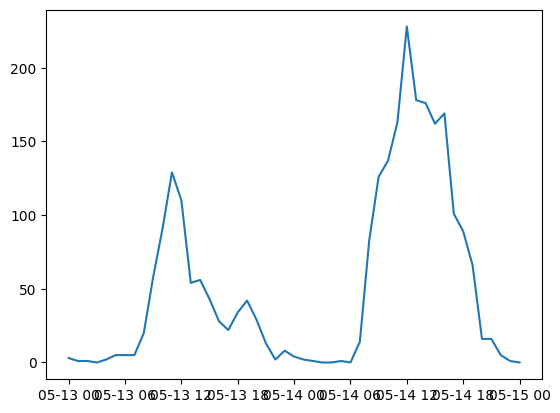

In [558]:
start = datetime(2023, 5, 13)
end = datetime(2023, 5, 15)
plt.plot(df['Estermannufer'][start:end])
#plt.plot(df['Estermannufer'])

In [559]:
bruecken = df.columns.values

In [560]:
#df[bruecken[0]][df.index.month==5]= df[bruecken[0]][df.index.month==5].fillna(value=list[bruecken[0]])
#df[df.isna().any(axis=1)]

In [561]:
#df.isna().sum()

In [562]:
# Moants mean
januar_mean = df[df.index.month==1].mean()
februar_mean = df[df.index.month==2].mean()
maerz_mean = df[df.index.month==3].mean()
april_mean = df[df.index.month==4].mean()
mai_mean = df[df.index.month==5].mean()
juni_mean = df[df.index.month==6].mean()
juli_mean = df[df.index.month==7].mean()
august_mean = df[df.index.month==8].mean()
september_mean = df[df.index.month==9].mean()
okt_mean = df[df.index.month==10].mean()
november_mean = df[df.index.month==11].mean()
dezember_mean = df[df.index.month==12].mean()
gesamt_mean = [januar_mean, februar_mean, maerz_mean, april_mean, mai_mean, juni_mean, juli_mean, august_mean, september_mean, okt_mean, november_mean, dezember_mean]
time_train_gesamt = df.index
X1 = df[bruecken].values
week_means1 = pd.DataFrame(X1, index=time_train_gesamt, columns=bruecken)
week_means1 = week_means1.groupby(week_means1.index.isocalendar().week)[week_means1.columns].mean()
df5 = pd.DataFrame(week_means1)

In [563]:
# mean monat
#for i in range(len(bruecken)):
#    print(bruecken[i])
#    for j in range(len(gesamt_mean)):
#        df[bruecken[i]][df.index.month==j+1] = df[bruecken[i]][df.index.month==j+1].fillna(value=gesamt_mean[j][bruecken[i]])
#        print(j)
#        print(df.isna().sum())

#df['Kennedybruecke (Nord)'] = df['Kennedybruecke (Nord)'].rolling(window=100).mean()
#df = df.ffill().bfill()
#df['Kennedybruecke (Nord)'] = df['Kennedybruecke (Nord)'].fillna(week_means1['Kennedybruecke (Nord)'])

# mean woche
woche=[]
for i in range(52):
    tmp = df5[bruecken][df5.index==i+1].values.tolist()
    woche.append(tmp)

for i in range(52):
    for j in range(len(bruecken)):
        start = df[bruecken][df.index.isocalendar().week==i+1].index
        anfang = start[0]
        ende = start[-1]
        df[bruecken[j]][anfang:ende].fillna(value=woche[i][0][j], inplace=True)

/tmp/ipykernel_58862/1245945104.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[bruecken[j]][anfang:ende].fillna(value=woche[i][0][j], inplace=True)
/tmp/ipykernel_58862/1245945104.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(

In [564]:

df[df.isna().any(axis=1)]

,Kennedybruecke (Nord),Kennedybruecke (Sued) Barometer,Nordbruecke (Sued),Nordbruecke (Nord),Suedbruecke (Sued),Suedbruecke (Nord),Estermannufer,Von-Sandt-Ufer,Rhenusallee,Broehltalweg,Bruehler Straße,Wilhelm-Spiritus-Ufer,Mc Cloy Weg,Weg auf Damm Neil,Kennedybruecke,Nordbruecke,Suedbruecke
time,,,,,,,,,,,,,,,,,


In [565]:
#plt.plot(df['Nordbruecke (Nord)']#[start:end])

In [566]:
print(df.isna().sum())

Kennedybruecke (Nord)              0
Kennedybruecke (Sued) Barometer    0
Nordbruecke (Sued)                 0
Nordbruecke (Nord)                 0
Suedbruecke (Sued)                 0
Suedbruecke (Nord)                 0
Estermannufer                      0
Von-Sandt-Ufer                     0
Rhenusallee                        0
Broehltalweg                       0
Bruehler Straße                    0
Wilhelm-Spiritus-Ufer              0
Mc Cloy Weg                        0
Weg auf Damm Neil                  0
Kennedybruecke                     0
Nordbruecke                        0
Suedbruecke                        0
dtype: int64


In [567]:
df.head()

,Kennedybruecke (Nord),Kennedybruecke (Sued) Barometer,Nordbruecke (Sued),Nordbruecke (Nord),Suedbruecke (Sued),Suedbruecke (Nord),Estermannufer,Von-Sandt-Ufer,Rhenusallee,Broehltalweg,Bruehler Straße,Wilhelm-Spiritus-Ufer,Mc Cloy Weg,Weg auf Damm Neil,Kennedybruecke,Nordbruecke,Suedbruecke
time,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,26.0,25.0,2.0,1.0,12.0,10.0,0.0,3.0,0.0,1.0,3.0,12.0,0.0,8.0,51.0,3.0,22.0
2023-01-01 01:00:00,46.0,88.0,11.0,2.0,15.0,10.0,1.0,5.0,0.0,10.0,13.0,26.0,2.0,12.0,134.0,13.0,25.0
2023-01-01 02:00:00,63.0,80.0,4.0,10.0,11.0,16.0,2.0,3.0,0.0,16.0,3.0,11.0,4.0,13.0,143.0,14.0,27.0
2023-01-01 03:00:00,34.0,66.0,6.0,3.0,16.0,5.0,2.0,3.0,0.0,2.0,6.0,7.0,3.0,10.0,100.0,9.0,21.0
2023-01-01 04:00:00,22.0,32.0,4.0,0.0,5.0,3.0,0.0,4.0,0.0,2.0,1.0,7.0,2.0,12.0,54.0,4.0,8.0


In [568]:
bruecken[1:2]

array(['Kennedybruecke (Sued) Barometer'], dtype=object)

In [569]:
#Regression
#X = df[bruecken[1:]].values
#y = df[[bruecken[0]]].values
#scaler_X = StandardScaler()
#x = scaler_X.fit_transform(X)
#scaler_y = StandardScaler()
#y = scaler_y.fit_transform(y)

In [570]:
#model = Sequential()
#model.add(Dense(units=1, input_shape=(16,)))
#model.summary()

In [571]:
#model.compile(loss='mse', optimizer='sgd')

In [572]:
#mse = MeanSquaredError()
#sgd = SGD(learning_rate=0.01)
#model.compile(loss=mse, optimizer=sgd)

In [573]:
#history = model.fit(X, y, epochs=5, batch_size=32)

In [574]:
#y_pred = model.predict(X)
#r2 = r2_score(y, y_pred)
#print(r2)

In [575]:
#X_pred = [januar_mean[1:]]
#X_pred = scaler_X.transform(X_pred)
#y_pred = model.predict(X_pred)
#y_pred = scaler_y.inverse_transform(y_pred)
#print(y_pred)

In [576]:
#loss_mse = history.history['loss']
#plt.plot(loss_mse)
#plt.show()

In [577]:
# Klassifizierer
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

In [578]:
#scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)
#X_train.shape, X_test.shape, y_train.shape, y_test.shape

In [579]:
#model_clas = Sequential()
#model_clas.add(Dense(units=16, input_shape=(16,), activation='relu', name='hidden'))
#model_clas.add(Dense(units=1, activation='sigmoid', name='output'))
#model_clas.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy'])
#model_clas.summary()

In [580]:
#epochs = 20
#batch_size = 32
#history = model_clas.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_test, y_test), verbose=False)
#loss, acc = model_clas.evaluate(X_test, y_test)
#print('accuracy: {:.5f}'.format(acc))

In [581]:
#accuracy_train = history.history['accuracy']
#loss_train = history.history['loss']
#accuracy_test = history.history['val_accuracy']
#loss_test = history.history['val_loss']
#plt.plot(accuracy_train)
#plt.plot(loss_train)
#plt.plot(accuracy_test)
#plt.plot(loss_test)

In [582]:
# Netz mit Generator
X = df[bruecken].values
y = df[[bruecken[0]]].values
split = ceil(len(df)* 0.8)
#time_train_gesamt = df.index
time_train = df[:split].index
time_test = df[split:].index
X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7008, 17), (1752, 17), (7008, 1), (1752, 1))

In [583]:
scaler_x = StandardScaler()
scaler_x.fit(X_train)
X_train = scaler_x.transform(X_train)
X_test = scaler_x.transform(X_test)
scaler_y = StandardScaler()
scaler_y.fit(y_train)
y_train = scaler_y.transform(y_train)
y_test = scaler_y.transform(y_test)

In [584]:
def data_generator(X, y, window=144, horizon=24, batch_size=1, epochs=10):
    for epoch in range(epochs):
        X_temp = []
        y_temp = []
        batch_counter = 0
        last_val = len(X) - (window + horizon)
        index_range = list(range(last_val))
        random.shuffle(index_range)
        for idx in index_range:
            X_idx = X[idx:idx+window]
            y_idx = y[idx+window+horizon]
            X_temp.append(X_idx)
            y_temp.append(y_idx)
            batch_counter += 1
            if (batch_counter == batch_size or index_range[-1] == idx):
                yield np.array(X_temp), np.array(y_temp).reshape(-1)
                X_temp = []
                y_temp = []
                batch_counter = 0

In [585]:
#test_gen = data_generator(X_train, y_train)
#X_, y_ = next(test_gen)
#print(X_.shape, y_.shape)

In [586]:
#reg = l2(0.0001)
#model = Sequential()
#model.add(Conv1D(filters=32, kernel_size=6, input_shape=(144, 17), activation='relu'))
#model.add(Dropout(0.3))
#model.add(Bidirectional(LSTM(units=32,dropout=0.3,kernel_regularizer=reg)))
#model.add(Dense(units=1, kernel_regularizer=reg))
#model.compile(loss='mse', optimizer='adam', metrics=['mae'])

In [587]:
#batch_size = 128
#epochs = 50
#window = 144
#horizon = 24

#gen_train = data_generator(X_train, y_train, batch_size=batch_size, epochs=epochs)
#gen_test = data_generator(X_test, y_test, batch_size=batch_size, epochs=epochs)

#early = EarlyStopping(monitor='val_loss', patience=1)
#check = ModelCheckpoint(filepath='Conv1D_model.keras', monitor='val_loss', save_best_only=True)

#steps_train = ceil(len(X_train-(window+horizon))/batch_size)
#steps_test = ceil(len(X_test-(window+horizon))/batch_size)

#history = model.fit(gen_train, epochs=epochs, steps_per_epoch=steps_train, validation_data=(gen_test), validation_steps=steps_test, callbacks=[early, check])

In [588]:
def predictions_vs_true(X_pred, y_true, model, scaler, window=144, horizon=24):
    X_temp=[]
    y_temp=[]
    y_temp_simple=[]
    num_pred = len(X_pred)-(window+horizon)
    for idx in range(num_pred):
        X_idx = X_pred[idx:idx+window]
        y_idx = y_true[idx+window+horizon]
        X_temp.append(X_idx)
        y_temp.append(y_idx)
        y_temp_simple.append(y_true[idx+window])
    X_temp = np.array(X_temp)
    y_pred = model.predict(X_temp)
    y_pred = scaler.inverse_transform(y_pred)
    y_temp = scaler.inverse_transform(y_temp)
    y_temp_simple = scaler.inverse_transform(y_temp_simple)
    return y_temp, y_pred, y_temp_simple

In [589]:
#model = load_model('Conv1D_model.keras')
#y_true, y_pred, y_simple = predictions_vs_true(X_test, y_test, model=model, scaler = scaler_y)

#print('mae, predictions', mean_absolute_error(y_true, y_pred))
#print('mae, simple pred', mean_absolute_error(y_simple, y_simple))

In [590]:
#plt.plot(history.history['loss'])
#plt.plot(history.history['val_loss'])
#plt.plot(history.history['mae'])
#plt.plot(history.history['val_mae'])

In [591]:
# Saisonales Model

In [592]:
week_means = pd.DataFrame(X, index=time_train_gesamt, columns=bruecken)
week_means = week_means.groupby(week_means.index.isocalendar().week)[week_means.columns].mean()
week_means

,Kennedybruecke (Nord),Kennedybruecke (Sued) Barometer,Nordbruecke (Sued),Nordbruecke (Nord),Suedbruecke (Sued),Suedbruecke (Nord),Estermannufer,Von-Sandt-Ufer,Rhenusallee,Broehltalweg,Bruehler Straße,Wilhelm-Spiritus-Ufer,Mc Cloy Weg,Weg auf Damm Neil,Kennedybruecke,Nordbruecke,Suedbruecke
week,,,,,,,,,,,,,,,,,
1,73.558333,180.511905,31.059524,17.845238,59.595238,49.803571,26.476190,62.708333,67.077381,25.458333,37.883333,104.029762,44.928571,79.029762,233.053571,48.904762,109.398810
2,89.904762,139.779762,24.238095,14.416667,40.738095,32.172619,19.583333,49.559524,0.000000,17.922619,22.388889,69.208333,38.059524,62.065476,229.684524,38.654762,72.910714
3,88.386905,144.440476,19.369048,10.690476,38.511905,29.101190,2.494048,22.785714,0.000000,13.714286,29.339286,51.345238,5.208333,39.369048,232.827381,30.059524,67.613095
4,93.065476,151.392857,20.500000,10.708333,40.077381,31.910714,8.398810,27.833333,0.000000,14.470238,29.184524,55.988095,16.000000,43.214286,244.458333,31.208333,71.988095
5,73.750000,166.065476,23.886905,13.184524,49.547619,41.577381,11.744048,37.720238,28.482143,18.476190,34.946429,72.351190,24.238095,52.130952,239.815476,37.071429,91.125000
6,109.708333,187.083333,35.250000,21.845238,62.458333,48.934524,36.952381,83.029762,120.972222,28.892857,62.000000,118.565476,63.785714,99.744048,265.446429,57.095238,111.392857
7,109.303571,169.672619,27.029762,14.982143,52.773810,41.910714,13.255952,40.696429,0.000000,20.113095,36.607143,76.321429,25.041667,60.821429,278.976190,42.011905,94.684524
8,97.119048,146.547619,24.267857,13.660714,44.589286,36.726190,12.666667,38.125000,0.000000,18.136905,30.583333,67.113095,25.940476,55.952381,243.666667,37.928571,81.315476
9,88.511905,218.773810,32.988095,18.446429,66.470238,52.613095,19.750000,53.386905,44.720238,24.684524,46.678571,100.303571,34.351190,78.738095,307.285714,51.434524,119.083333


In [593]:
def data_generator_seasonal(X: np.array, y: np.array, mean_tab: pd.DataFrame, y_index: pd.Index, window=144, horizon=24, season=24, batch_size=1, epochs=10):
    for epoch in range(epochs):
        X_s, X_m, y_ = [], [], []
        batch_counter = 0
        last_val = len(X) - (window + horizon)
        index_range = list(range(last_val))
        random.shuffle(index_range)
        for idx in index_range:
            season_range = range(window+idx-1, idx-1, -season)
            X_s.append([X[i] for i in season_range])
            y_date = y_index[idx+window+horizon]
            y_mean = mean_tab.loc[y_date.week]
            X_m.append(y_mean.values)
            y_.append(y[idx+window+horizon])
            batch_counter += 1
            if (batch_counter == batch_size or index_range[-1] == idx):
                yield ((np.array(X_s), np.array(X_m)), np.array(y_))
                X_s, X_m, y_ = [], [], []
                batch_counter = 0

test_gen = data_generator_seasonal(X_train, y_train, mean_tab=week_means, y_index=time_train)
(x_s, x_m), y_ = next(test_gen)
print(x_s.shape, x_m.shape, y_.shape)

(1, 6, 17) (1, 17) (1, 1)


In [594]:
batch_size = 128
epochs = 100
window = 144
horizon = 24
indicators = 17
num_seasons = 12
reg = l2(0.0001)

input_sn = Input(shape=(num_seasons, indicators), name='in_sn')
input_mn = Input(shape=(indicators,), name='in_mn')

sn = GRU(units=32, dropout=0.3, go_backwards=True, kernel_regularizer=reg, name='sn_gru')(input_sn)
mn = Dense(units=indicators, activation='tanh', kernel_regularizer=reg)(input_mn)
mn = Dropout(0.2)(mn)
comp = concatenate([sn, mn], axis=-1)
comp = Dense(units=1, kernel_regularizer=reg)(comp)

model_seasonal = Model([input_sn, input_mn], comp)
model_seasonal.compile(loss='mse', optimizer='adam', metrics=['mae'])

In [595]:
gen_train_seasonal = data_generator_seasonal(X_train, y_train, mean_tab=week_means, y_index=time_train, window=window, horizon=horizon, season=num_seasons, batch_size=batch_size, epochs=epochs)
gen_test_seasonal = data_generator_seasonal(X_test, y_test, mean_tab=week_means, y_index=time_test, window=window, horizon=horizon, season=num_seasons, batch_size=batch_size, epochs=epochs)

early = EarlyStopping(monitor='val_loss', patience=10)
check = ModelCheckpoint(filepath='Seasonal_model.keras', monitor='val_loss', save_best_only=True)

steps_train = ceil(len(X_train-(window+horizon))/batch_size)
steps_test = ceil(len(X_test-(window+horizon))/batch_size)

history_seasonal = model_seasonal.fit(gen_train_seasonal, epochs=epochs, steps_per_epoch=steps_train, validation_data=(gen_test_seasonal), validation_steps=steps_test, callbacks=[early, check])

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.0736 - mae: 0.7922 - val_loss: 0.5257 - val_mae: 0.5420
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8477 - mae: 0.6798 - val_loss: 0.4931 - val_mae: 0.5136
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7568 - mae: 0.6307 - val_loss: 0.4412 - val_mae: 0.4261
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6919 - mae: 0.5911 - val_loss: 0.4016 - val_mae: 0.4112
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6539 - mae: 0.5730 - val_loss: 0.4421 - val_mae: 0.4154
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6539 - mae: 0.5747 - val_loss: 0.3953 - val_mae: 0.4173
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6178 - mae: 0.5535 - val_loss: 0.4064 - val_mae: 0.4437
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6104 - mae: 0.5506 - val_loss: 0.3861 - val_mae: 0.4394
Epoch 9/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.56

Text(0, 0.5, 'loss')

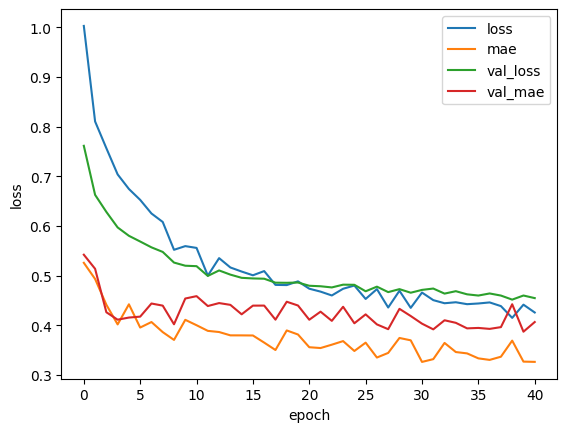

In [596]:
plt.plot(history_seasonal.history['loss'])
plt.plot(history_seasonal.history['val_loss'])
plt.plot(history_seasonal.history['mae'])
plt.plot(history_seasonal.history['val_mae'])
plt.legend(['loss', 'mae', 'val_loss', 'val_mae'])
plt.xlabel('epoch')
plt.ylabel('loss')

In [597]:
model_seasonal.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ in_mn (InputLayer)  │ (None, 17)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_sn (InputLayer)  │ (None, 12, 17)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 17)        │        306 │ in_mn[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sn_gru (GRU)        │ (None, 32)        │      4,896 │ in_sn[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 17)        │          0 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 49)        │          0 │ sn_gru[0][0],     │
│ (Concatenate)       │                   │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 1)         │         50 │ concatenate_8[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,758 (61.56 KB)

 Trainable params: 5,252 (20.52 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,506 (41.04 KB)

In [598]:
print(X_train)

[[-0.67237301 -1.00808291 -0.88739879 ... -0.9266301  -0.89496323
  -0.77757628]
 [-0.46841525 -0.64299243 -0.66476466 ... -0.5841305  -0.73641991
  -0.75467134]
 [-0.29505115 -0.68935312 -0.83792454 ... -0.54699198 -0.72056558
  -0.73940138]
 ...
 [-0.06049971 -0.30687738 -0.59055328 ... -0.17973337 -0.67300258
  -0.6554166 ]
 [-0.22366593 -0.27210686 -0.64002754 ... -0.22099839 -0.65714825
  -0.72413142]
 [-0.61118568 -0.7878696  -0.83792454 ... -0.74506404 -0.84740023
  -0.86919605]]


In [599]:
time_train

DatetimeIndex(['2023-01-01 00:00:00', '2023-01-01 01:00:00',
               '2023-01-01 02:00:00', '2023-01-01 03:00:00',
               '2023-01-01 04:00:00', '2023-01-01 05:00:00',
               '2023-01-01 06:00:00', '2023-01-01 07:00:00',
               '2023-01-01 08:00:00', '2023-01-01 09:00:00',
               ...
               '2023-10-19 14:00:00', '2023-10-19 15:00:00',
               '2023-10-19 16:00:00', '2023-10-19 17:00:00',
               '2023-10-19 18:00:00', '2023-10-19 19:00:00',
               '2023-10-19 20:00:00', '2023-10-19 21:00:00',
               '2023-10-19 22:00:00', '2023-10-19 23:00:00'],
              dtype='datetime64[ns]', name='time', length=7008, freq=None)